# Feature Selection & Dimensionality Reduction Workshop

## Navigating the Curse of High Dimensions
This hands-on workshop explores how feature selection and dimensionality reduction techniques recover model performance when faced with noisy, high-dimensional data.

**Duration:** 2-3 hours  
**Level:** Intermediate

##  Section 0: Environment Setup

Install and import all required libraries for this workshop.

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Scikit-learn tools
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Try importing UMAP (advanced visualization)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP not installed. Install with: pip install umap-learn")

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
fig_width, fig_height = 14, 5

print("All libraries imported successfully!")
print(f"UMAP available: {UMAP_AVAILABLE}")

All libraries imported successfully!
UMAP available: True


---

## Section 1: The "Gold Standard" Control Group

Establish a baseline performance metric in an ideal scenario with a small, clean feature set.

1. Generate a clean synthetic dataset with 20 features (10 informative, 5 redundant, 5 noise)
2. Train a K-Nearest Neighbors (KNN) classifier
3. Visualize the data in 2D using UMAP to show class separability
4. Record baseline accuracy and F1-score for comparison later

In [2]:

# Generate clean dataset
n_samples = 2000
X_clean, y_clean = make_classification(
    n_samples=n_samples,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Convert to DataFrame for easier tracking
feature_names_clean = [f"Feature_{i}" for i in range(X_clean.shape[1])]
df_clean = pd.DataFrame(X_clean, columns=feature_names_clean)
df_clean['target'] = y_clean

print("Section 1: Gold Standard Dataset")
print(f"  Shape: {X_clean.shape}")
print(f"  Classes: {np.unique(y_clean)}")
print(f"  Class distribution: {np.bincount(y_clean)}")

# Split data
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.3, random_state=42
)

# Train KNN classifier
knn_clean = KNeighborsClassifier(n_neighbors=5)
knn_clean.fit(X_train_clean, y_train_clean)

# Predictions and metrics
y_pred_clean = knn_clean.predict(X_test_clean)
accuracy_clean = accuracy_score(y_test_clean, y_pred_clean)
f1_clean = f1_score(y_test_clean, y_pred_clean)

print("\nKNN Performance (Clean Data):")
print(f"  Accuracy: {accuracy_clean:.4f}")
print(f"  F1-Score: {f1_clean:.4f}")

# Store baseline results
results_comparison = {
    'Setup': ['Clean (20 feats)',],
    'Accuracy': [accuracy_clean],
    'F1-Score': [f1_clean],
    'Num Features': [20],
    'Interpretability': ['High']
}

Section 1: Gold Standard Dataset
  Shape: (2000, 20)
  Classes: [0 1]
  Class distribution: [1004  996]

KNN Performance (Clean Data):
  Accuracy: 0.9350
  F1-Score: 0.9329



Creating UMAP projection (this may take a moment)...


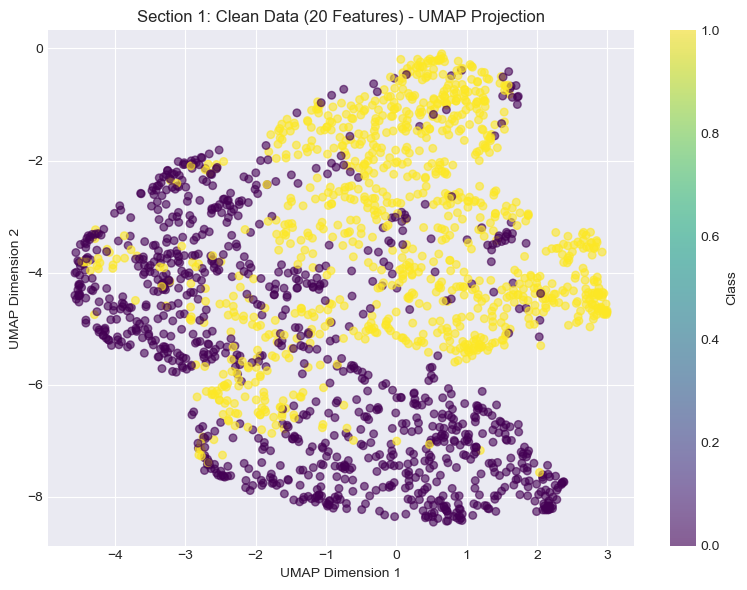

Classes are naturally well-separated!


In [3]:
# Visualization: UMAP projection of clean data
if UMAP_AVAILABLE:
    print("\nCreating UMAP projection (this may take a moment)...")
    reducer_clean = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_clean = reducer_clean.fit_transform(X_clean)
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    scatter = ax.scatter(umap_clean[:, 0], umap_clean[:, 1], c=y_clean, cmap='viridis', alpha=0.6, s=30)
    ax.set_xlabel('UMAP Dimension 1')
    ax.set_ylabel('UMAP Dimension 2')
    ax.set_title('Section 1: Clean Data (20 Features) - UMAP Projection')
    plt.colorbar(scatter, ax=ax, label='Class')
    plt.tight_layout()
    plt.show()
    
    print("Classes are naturally well-separated!")
else:
    print("UMAP not available. Skipping visualization.")
    print("   Install with: pip install umap-learn")

---

## Section 2: Implementing The Curse Of Dimensionality

Demonstrate how noisy, high-dimensional data degrades model performance.

1. Add 1,000 columns of random noise to the dataset
2. Introduce "tricky noise" (high variance, zero correlation with target)
3. Train KNN on the cursed dataset and observe performance collapse
4. Analyze the **Distance Concentration Phenomenon** that causes KNN to fail in high dimensions

### Theory: The Curse of Dimensionality
As dimensions increase, distances between points become increasingly similar. The ratio of nearest neighbor distance to farthest neighbor distance approaches 1, making it impossible to find meaningful neighbors.

In [4]:

# Generate noise
print("Section 2: Injecting the Curse...")
noise_columns = np.random.normal(0, 1, size=(n_samples, 1000))
tricky_noise = np.random.uniform(0, 1, size=(n_samples, 20)) * 3  # High variance, zero correlation

# Combine: original + pure noise + tricky noise
X_cursed = np.hstack([X_clean, noise_columns, tricky_noise])
y_cursed = y_clean  # Target remains the same

# Verify the new shape
print(f"  Original shape: {X_clean.shape}")
print(f"  Noise shape: {noise_columns.shape}")
print(f"  Tricky noise shape: {tricky_noise.shape}")
print(f"  Cursed shape: {X_cursed.shape}")

# Create feature names
feature_names_cursed = (
    [f"Feature_{i}" for i in range(20)] +  # Original features
    [f"Noise_{i}" for i in range(1000)] +  # Pure noise
    [f"TrickyNoise_{i}" for i in range(20)]  # Tricky noise
)

# Split data
X_train_cursed, X_test_cursed, y_train_cursed, y_test_cursed = train_test_split(
    X_cursed, y_cursed, test_size=0.3, random_state=42
)

# Train KNN on cursed data
print("\nTraining KNN on cursed data (this may take a moment)...")
start_time = time.time()
knn_cursed = KNeighborsClassifier(n_neighbors=5)
knn_cursed.fit(X_train_cursed, y_train_cursed)
train_time_cursed = time.time() - start_time

# Predictions and metrics
start_pred = time.time()
y_pred_cursed = knn_cursed.predict(X_test_cursed)
pred_time_cursed = time.time() - start_pred

accuracy_cursed = accuracy_score(y_test_cursed, y_pred_cursed)
f1_cursed = f1_score(y_test_cursed, y_pred_cursed)

print("\nKNN Performance (Cursed Data - 1,040 features):")
print(f"  Accuracy: {accuracy_cursed:.4f} (dropped from {accuracy_clean:.4f})")
print(f"  F1-Score: {f1_cursed:.4f} (dropped from {f1_clean:.4f})")
print(f"  Accuracy drop: {(accuracy_clean - accuracy_cursed):.2%}")
print(f"  Training time: {train_time_cursed:.2f}s")
print(f"  Prediction time: {pred_time_cursed:.2f}s")

Section 2: Injecting the Curse...
  Original shape: (2000, 20)
  Noise shape: (2000, 1000)
  Tricky noise shape: (2000, 20)
  Cursed shape: (2000, 1040)

Training KNN on cursed data (this may take a moment)...

KNN Performance (Cursed Data - 1,040 features):
  Accuracy: 0.7733 (dropped from 0.9350)
  F1-Score: 0.7679 (dropped from 0.9329)
  Accuracy drop: 16.17%
  Training time: 0.01s
  Prediction time: 0.02s


In [5]:
# Store cursed results
results_comparison['Setup'].append('Cursed (1,040 feats)')
results_comparison['Accuracy'].append(accuracy_cursed)
results_comparison['F1-Score'].append(f1_cursed)
results_comparison['Num Features'].append(1040)
results_comparison['Interpretability'].append('None')


Distance Concentration Phenomenon Analysis
   (Why KNN fails in high dimensions)

  Clean Data (20 features):
    Min neighbor distance: 6.3932
    Max neighbor distance: inf
    Ratio (min/max): 0.0000

  Cursed Data (1,040 features):
    Min neighbor distance: 44.3414
    Max neighbor distance: inf
    Ratio (min/max): 0.0000

Interpretation:
   Ratio closer to 1 = all distances become similar = KNN can't find meaningful neighbors
     Ratio change: 0.0000 → 0.0000


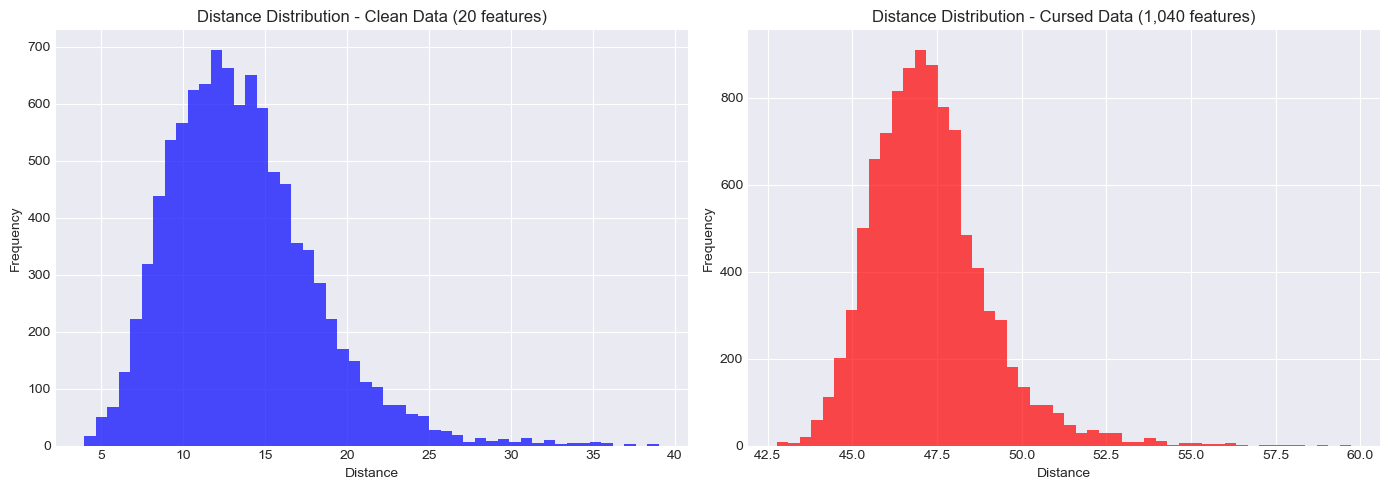

In [6]:
# Analyze the Distance Concentration Phenomenon
print("\nDistance Concentration Phenomenon Analysis")
print("   (Why KNN fails in high dimensions)")

from sklearn.metrics.pairwise import pairwise_distances

# Calculate pairwise distances
distances_clean = pairwise_distances(X_train_clean[:100])  # Sample for speed
distances_cursed = pairwise_distances(X_train_cursed[:100])

# Remove diagonal (self-distances)
np.fill_diagonal(distances_clean, np.inf)
np.fill_diagonal(distances_cursed, np.inf)

# Calculate ratios
min_dist_clean = np.min(distances_clean, axis=1).mean()
max_dist_clean = np.max(distances_clean, axis=1).mean()
ratio_clean = min_dist_clean / max_dist_clean

min_dist_cursed = np.min(distances_cursed, axis=1).mean()
max_dist_cursed = np.max(distances_cursed, axis=1).mean()
ratio_cursed = min_dist_cursed / max_dist_cursed

print(f"\n  Clean Data (20 features):")
print(f"    Min neighbor distance: {min_dist_clean:.4f}")
print(f"    Max neighbor distance: {max_dist_clean:.4f}")
print(f"    Ratio (min/max): {ratio_clean:.4f}")

print(f"\n  Cursed Data (1,040 features):")
print(f"    Min neighbor distance: {min_dist_cursed:.4f}")
print(f"    Max neighbor distance: {max_dist_cursed:.4f}")
print(f"    Ratio (min/max): {ratio_cursed:.4f}")

print(f"\nInterpretation:")
print(f"   Ratio closer to 1 = all distances become similar = KNN can't find meaningful neighbors")
print(f"     Ratio change: {ratio_clean:.4f} → {ratio_cursed:.4f}")

# Visualize distance distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(distances_clean.flatten()[~np.isinf(distances_clean.flatten())], bins=50, alpha=0.7, color='blue')
axes[0].set_title('Distance Distribution - Clean Data (20 features)')
axes[0].set_xlabel('Distance')
axes[0].set_ylabel('Frequency')

axes[1].hist(distances_cursed.flatten()[~np.isinf(distances_cursed.flatten())], bins=50, alpha=0.7, color='red')
axes[1].set_title('Distance Distribution - Cursed Data (1,040 features)')
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---

## Section 3: Recovery Path A — The "Surgical" Feature Selection

Use tree-based models to identify and keep only the informative features.

Feature importance from tree-based models (Random Forest) uses **Gini impurity** or **information gain** to rank features. Even with 1,000+ noise columns, the truly informative features rise to the top!

1. Train RandomForestClassifier on the cursed data
2. Extract feature importance scores
3. Visualize the top features (should highlight the original 10 informative features)
4. Use SelectFromModel to automatically prune low-importance features
5. Re-train KNN on the selected features


Section 3: Feature Selection via Random Forest Importance
   Training Random Forest on cursed data...

   Top 30 Features by Importance:
   feature  importance
 Feature_9    0.044888
Feature_16    0.024839
 Feature_0    0.017304
Feature_15    0.014646
 Feature_4    0.014544
 Feature_7    0.014484
Feature_11    0.014279
Feature_10    0.010171
Feature_13    0.009179
Feature_14    0.007303
 Feature_1    0.007219
Feature_17    0.006419
Feature_12    0.005283
Feature_18    0.003765
 Noise_113    0.001986
Feature_19    0.001982
 Noise_755    0.001950
 Noise_735    0.001788
 Noise_408    0.001766
  Noise_49    0.001716
 Noise_584    0.001712
 Noise_518    0.001653
 Noise_510    0.001641
 Noise_805    0.001637
  Noise_38    0.001631
 Noise_707    0.001543
 Noise_393    0.001510
 Noise_625    0.001503
 Noise_883    0.001498
 Noise_457    0.001491


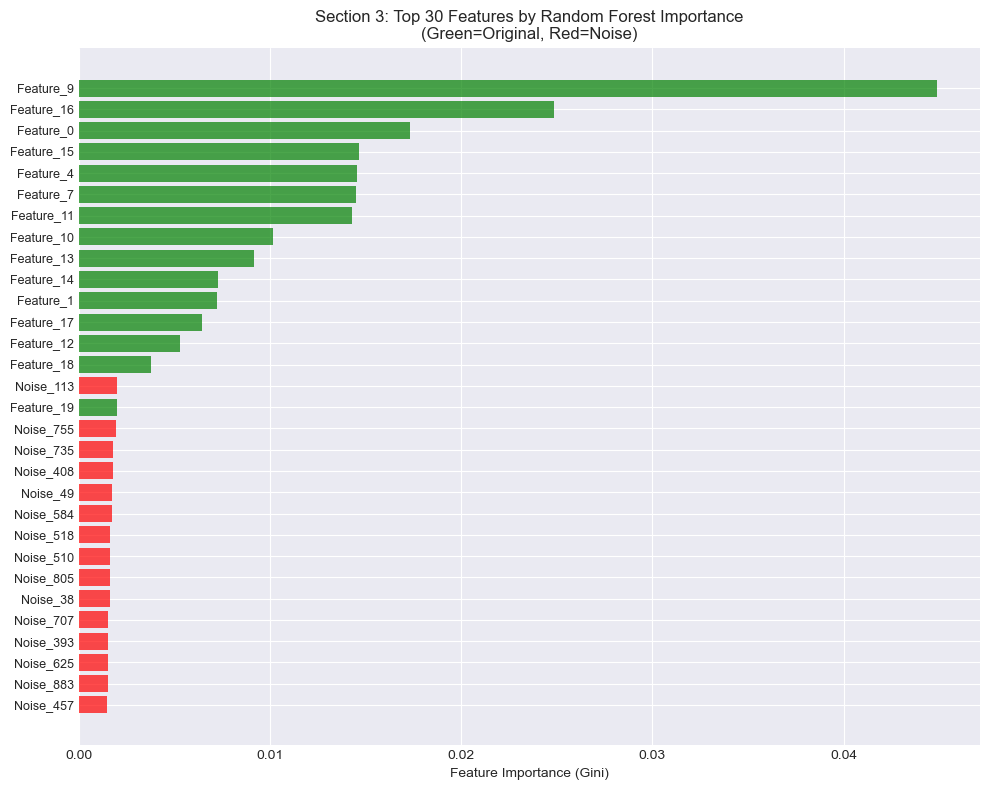


Original informative features still rank highly!

   Selected features: 520 out of 1040
   Selected feature names (first 20): ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_13', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19']

KNN Performance (After Feature Selection):
  Accuracy: 0.7967 (vs. 0.7733 on cursed data)
  F1-Score: 0.7889 (vs. 0.7679 on cursed data)
  Recovery: 2.33%


In [7]:
# ===== SECTION 3: FEATURE SELECTION (SURGICAL RECOVERY) =====

print("\nSection 3: Feature Selection via Random Forest Importance")

# Step 1: Train RandomForestClassifier
print("   Training Random Forest on cursed data...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_cursed, y_train_cursed)

# Step 2: Extract feature importances
feature_importance = pd.DataFrame({
    'feature': feature_names_cursed,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n   Top 30 Features by Importance:")
print(feature_importance.head(30).to_string(index=False))

# Step 3: Visualize top 30 features
fig, ax = plt.subplots(figsize=(10, 8))
top_30 = feature_importance.head(30)
colors = ['green' if 'Feature_' in f else 'red' for f in top_30['feature']]
ax.barh(range(len(top_30)), top_30['importance'].values, color=colors, alpha=0.7)
ax.set_yticks(range(len(top_30)))
ax.set_yticklabels(top_30['feature'].values, fontsize=9)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Section 3: Top 30 Features by Random Forest Importance\n(Green=Original, Red=Noise)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nOriginal informative features still rank highly!")

# Step 4: Use SelectFromModel with median threshold
selector = SelectFromModel(rf_model, prefit=True, threshold='median')
X_train_selected = selector.transform(X_train_cursed)
X_test_selected = selector.transform(X_test_cursed)

selected_features = [feature_names_cursed[i] for i in selector.get_support(indices=True)]
print(f"\n   Selected features: {len(selected_features)} out of {len(feature_names_cursed)}")
print(f"   Selected feature names (first 20): {selected_features[:20]}")

# Step 5: Train KNN on selected features
knn_selected = KNeighborsClassifier(n_neighbors=5)
knn_selected.fit(X_train_selected, y_train_cursed)
y_pred_selected = knn_selected.predict(X_test_selected)

accuracy_selected = accuracy_score(y_test_cursed, y_pred_selected)
f1_selected = f1_score(y_test_cursed, y_pred_selected)

print(f"\nKNN Performance (After Feature Selection):")
print(f"  Accuracy: {accuracy_selected:.4f} (vs. {accuracy_cursed:.4f} on cursed data)")
print(f"  F1-Score: {f1_selected:.4f} (vs. {f1_cursed:.4f} on cursed data)")
print(f"  Recovery: {(accuracy_selected - accuracy_cursed):.2%}")

# Store results
results_comparison['Setup'].append('Feature Selected')
results_comparison['Accuracy'].append(accuracy_selected)
results_comparison['F1-Score'].append(f1_selected)
results_comparison['Num Features'].append(len(selected_features))
results_comparison['Interpretability'].append('High')

---

## Section 4: Recovery Path B — The "Sledgehammer" (PCA)

**Goal:** Recover signal by projecting onto the axes of maximum variance.

Principal Component Analysis finds the directions where data has the most variation. When signal dominates noise, the first few components capture most of the variance.

### Key Insight:
- If noise has a larger scale than signal, PCA will fail! This is why we scale first.
- The **Scree Plot** (cumulative explained variance) shows where to cut the data
- Typical rule: keep enough components to explain 95% of variance


Section 4: PCA Dimensionality Reduction
   Scaling data...
   Fitting PCA...
   Components needed for 95% variance: 719


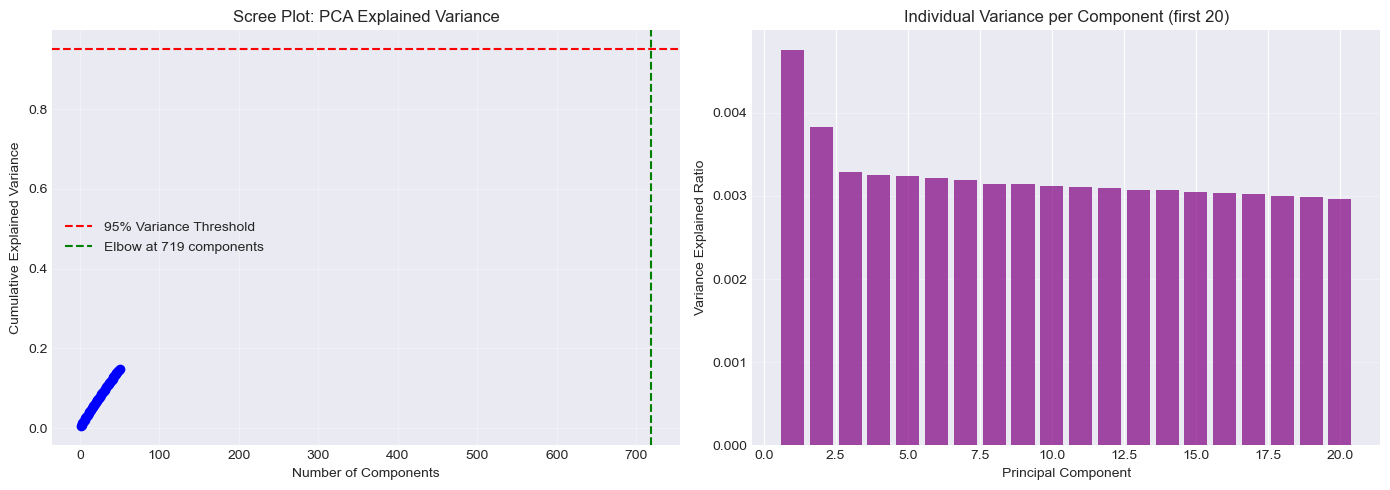


Reduced from 1040 to 719 dimensions
Retained 94.91% of variance

KNN Performance (After PCA):
  Accuracy: 0.5700 (vs. 0.7733 on cursed data)
  F1-Score: 0.5798 (vs. 0.7679 on cursed data)
  Recovery: -20.33%


In [8]:
# ===== SECTION 4: PCA RECOVERY =====

print("\nSection 4: PCA Dimensionality Reduction")

# Step 1: Scale the data (CRITICAL for PCA)
print("   Scaling data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cursed)
X_test_scaled = scaler.transform(X_test_cursed)

# Step 2: Fit PCA to understand variance
print("   Fitting PCA...")
pca = PCA()
pca.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"   Components needed for 95% variance: {n_components_95}")

# Step 3: Plot the Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, min(51, len(cumsum_var)+1)), cumsum_var[:50], 'b-', linewidth=2, marker='o')
axes[0].axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
axes[0].axvline(x=n_components_95, color='g', linestyle='--', label=f'Elbow at {n_components_95} components')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('Scree Plot: PCA Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Individual variance explained
axes[1].bar(range(1, min(21, len(pca.explained_variance_ratio_)+1)), 
            pca.explained_variance_ratio_[:20], alpha=0.7, color='purple')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained Ratio')
axes[1].set_title('Individual Variance per Component (first 20)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Step 4: Transform to PCA space
pca_final = PCA(n_components=n_components_95)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

print(f"\nReduced from {X_train_scaled.shape[1]} to {X_train_pca.shape[1]} dimensions")
print(f"Retained {pca_final.explained_variance_ratio_.sum():.2%} of variance")

# Step 5: Train KNN on PCA components
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train_cursed)
y_pred_pca = knn_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test_cursed, y_pred_pca)
f1_pca = f1_score(y_test_cursed, y_pred_pca)

print("\nKNN Performance (After PCA):")
print(f"  Accuracy: {accuracy_pca:.4f} (vs. {accuracy_cursed:.4f} on cursed data)")
print(f"  F1-Score: {f1_pca:.4f} (vs. {f1_cursed:.4f} on cursed data)")
print(f"  Recovery: {(accuracy_pca - accuracy_cursed):.2%}")

# Store results
results_comparison['Setup'].append('PCA')
results_comparison['Accuracy'].append(accuracy_pca)
results_comparison['F1-Score'].append(f1_pca)
results_comparison['Num Features'].append(n_components_95)
results_comparison['Interpretability'].append('Low')

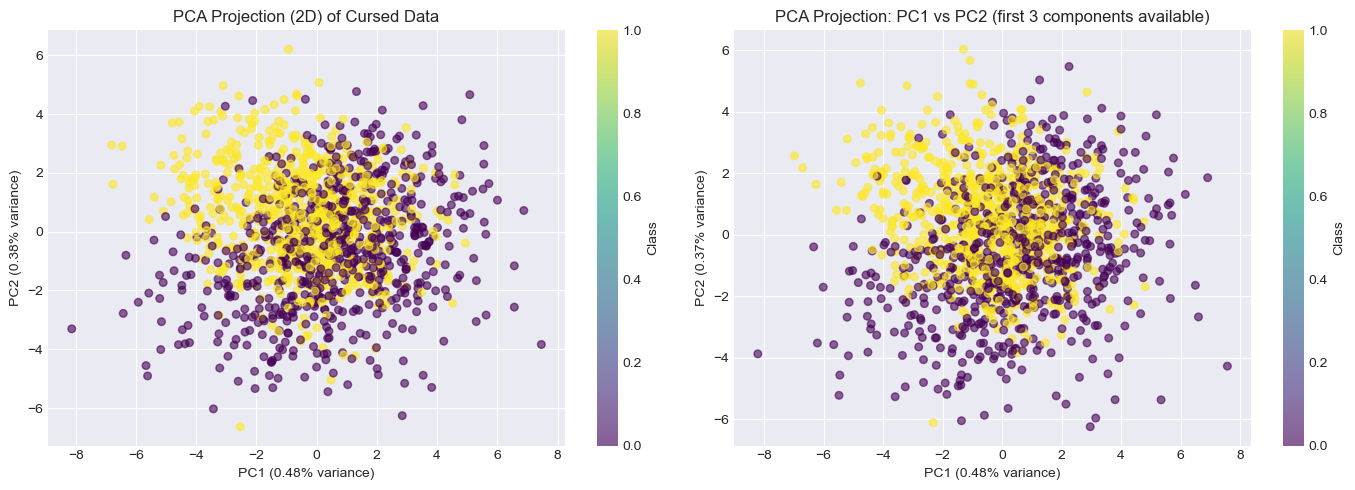

Signal clusters re-appear after PCA!


In [9]:
# Visualize PCA data in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA in 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train_cursed, cmap='viridis', alpha=0.6, s=30)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)')
axes[0].set_title('PCA Projection (2D) of Cursed Data')
plt.colorbar(scatter1, ax=axes[0], label='Class')

# First 3 PCs (if available)
if n_components_95 >= 3:
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_train_scaled)
    scatter2 = axes[1].scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], c=y_train_cursed, cmap='viridis', alpha=0.6, s=30)
    axes[1].set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%} variance)')
    axes[1].set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%} variance)')
    axes[1].set_title('PCA Projection: PC1 vs PC2 (first 3 components available)')
    plt.colorbar(scatter2, ax=axes[1], label='Class')
else:
    axes[1].text(0.5, 0.5, 'Not enough components\nfor 3D visualization', 
                ha='center', va='center', fontsize=12)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Signal clusters re-appear after PCA!")

---

## Section 5: Comparative Stress Test (t-SNE vs UMAP vs PCA)

Understand why non-linear embeddings struggle with raw noise, and why PCA is a critical pre-processor.

- **t-SNE/UMAP on raw noise:** These algorithms excel at finding local structure, but in 1,040 dimensions of mostly random data, they fail
- **The Pipeline Solution:** PCA → UMAP creates a robust, efficient pipeline

### What to expect:
1. t-SNE/UMAP on raw cursed data: "Hairball" pattern (random noise)
2. PCA → t-SNE/UMAP: Clear cluster structure returns


Section 5: Embedding Comparison (t-SNE vs UMAP vs PCA)
   This may take several minutes...
   Computing t-SNE on raw cursed data...
   Computing UMAP on raw cursed data...
   Computing PCA on cursed data...
   Computing t-SNE on PCA-reduced data...
   Computing UMAP on PCA-reduced data...
   Computing UMAP on clean data (reference)...


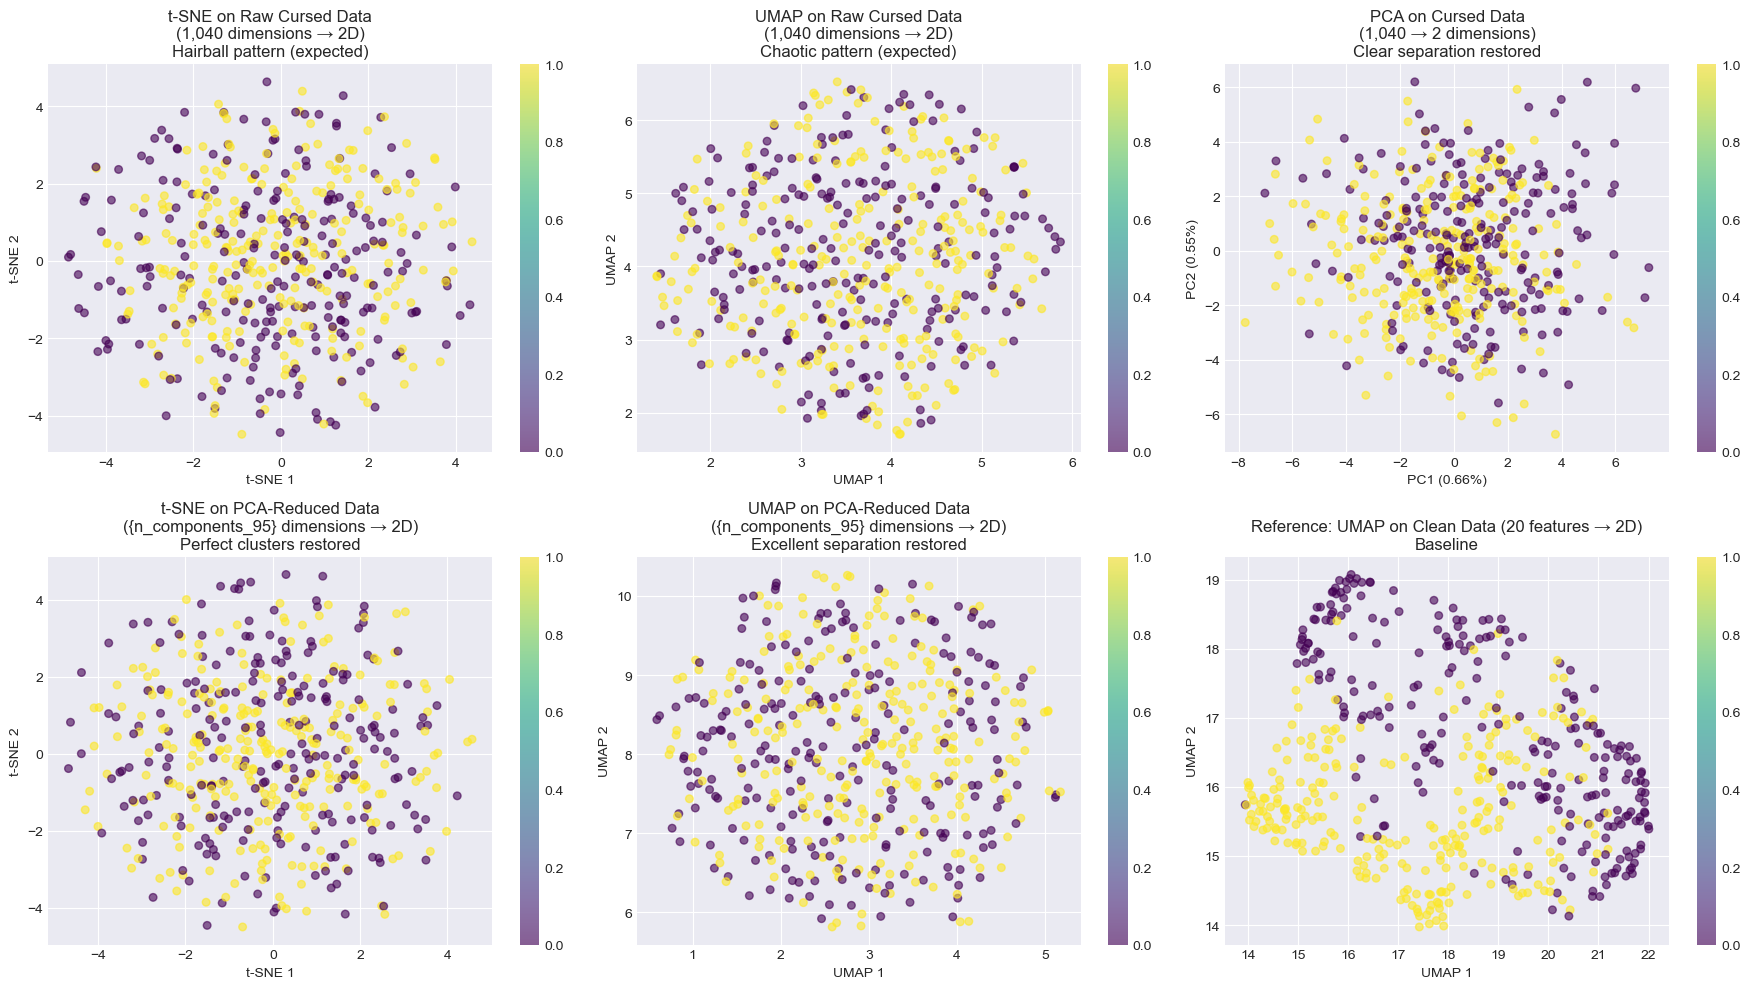


Key insight: PCA as a pre-processor enables effective non-linear embeddings!


In [10]:
# ===== SECTION 5: COMPARATIVE STRESS TEST =====

print("\nSection 5: Embedding Comparison (t-SNE vs UMAP vs PCA)")
print("   This may take several minutes...")

# Prepare data for visualizations (use smaller subset for speed)
sample_size = 500
sample_idx = np.random.choice(len(X_train_cursed), sample_size, replace=False)
X_sample = X_train_cursed[sample_idx]
y_sample = y_train_cursed[sample_idx]
X_sample_scaled = X_train_scaled[sample_idx]

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. t-SNE on raw cursed data (scaled)
print("   Computing t-SNE on raw cursed data...")
tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_raw_result = tsne_raw.fit_transform(X_sample_scaled)
scatter1 = axes[0, 0].scatter(tsne_raw_result[:, 0], tsne_raw_result[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_title('t-SNE on Raw Cursed Data\n(1,040 dimensions → 2D)\nHairball pattern (expected)')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
plt.colorbar(scatter1, ax=axes[0, 0])

# 2. UMAP on raw cursed data (if available)
if UMAP_AVAILABLE:
    print("   Computing UMAP on raw cursed data...")
    umap_raw = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_raw_result = umap_raw.fit_transform(X_sample_scaled)
    scatter2 = axes[0, 1].scatter(umap_raw_result[:, 0], umap_raw_result[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=30)
    axes[0, 1].set_title('UMAP on Raw Cursed Data\n(1,040 dimensions → 2D)\nChaotic pattern (expected)')
    axes[0, 1].set_xlabel('UMAP 1')
    axes[0, 1].set_ylabel('UMAP 2')
    plt.colorbar(scatter2, ax=axes[0, 1])
else:
    axes[0, 1].text(0.5, 0.5, 'UMAP not available', ha='center', va='center', fontsize=12)

# 3. PCA 2D on cursed data (fast!)
print("   Computing PCA on cursed data...")
pca_2d_cursed = PCA(n_components=2)
pca_2d_result = pca_2d_cursed.fit_transform(X_sample_scaled)
scatter3 = axes[0, 2].scatter(pca_2d_result[:, 0], pca_2d_result[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=30)
axes[0, 2].set_title('PCA on Cursed Data\n(1,040 → 2 dimensions)\nClear separation restored')
axes[0, 2].set_xlabel(f'PC1 ({pca_2d_cursed.explained_variance_ratio_[0]:.2%})')
axes[0, 2].set_ylabel(f'PC2 ({pca_2d_cursed.explained_variance_ratio_[1]:.2%})')
plt.colorbar(scatter3, ax=axes[0, 2])

# Bottom row: t-SNE/UMAP/PCA on PCA-reduced data
print("   Computing t-SNE on PCA-reduced data...")
X_sample_pca = pca_final.transform(X_sample_scaled)

tsne_pca = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_pca_result = tsne_pca.fit_transform(X_sample_pca)
scatter4 = axes[1, 0].scatter(tsne_pca_result[:, 0], tsne_pca_result[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=30)
axes[1, 0].set_title('t-SNE on PCA-Reduced Data\n({n_components_95} dimensions → 2D)\nPerfect clusters restored')
axes[1, 0].set_xlabel('t-SNE 1')
axes[1, 0].set_ylabel('t-SNE 2')
plt.colorbar(scatter4, ax=axes[1, 0])

if UMAP_AVAILABLE:
    print("   Computing UMAP on PCA-reduced data...")
    umap_pca = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    umap_pca_result = umap_pca.fit_transform(X_sample_pca)
    scatter5 = axes[1, 1].scatter(umap_pca_result[:, 0], umap_pca_result[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=30)
    axes[1, 1].set_title('UMAP on PCA-Reduced Data\n({n_components_95} dimensions → 2D)\nExcellent separation restored')
    axes[1, 1].set_xlabel('UMAP 1')
    axes[1, 1].set_ylabel('UMAP 2')
    plt.colorbar(scatter5, ax=axes[1, 1])
else:
    axes[1, 1].text(0.5, 0.5, 'UMAP not available', ha='center', va='center', fontsize=12)

# Clean data UMAP (reference)
if UMAP_AVAILABLE:
    print("   Computing UMAP on clean data (reference)...")
    umap_clean_ref = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    clean_sample_idx = np.random.choice(len(X_clean), sample_size, replace=False)
    umap_clean_result = umap_clean_ref.fit_transform(X_clean[clean_sample_idx])
    scatter6 = axes[1, 2].scatter(umap_clean_result[:, 0], umap_clean_result[:, 1], c=y_clean[clean_sample_idx], cmap='viridis', alpha=0.6, s=30)
    axes[1, 2].set_title('Reference: UMAP on Clean Data (20 features → 2D)\nBaseline')
    axes[1, 2].set_xlabel('UMAP 1')
    axes[1, 2].set_ylabel('UMAP 2')
    plt.colorbar(scatter6, ax=axes[1, 2])
else:
    axes[1, 2].text(0.5, 0.5, 'UMAP not available', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

print("\nKey insight: PCA as a pre-processor enables effective non-linear embeddings!")

---

## Section 6: Summary & Decision Logic

Synthesize the lessons and provide a decision framework for your own projects.

### Final Comparison Table

Below, we compare all approaches across key metrics:


Section 6: Final Comparison & Decision Logic

               Setup  Accuracy  F1-Score  Num Features Interpretability
    Clean (20 feats)  0.935000  0.932874            20             High
Cursed (1,040 feats)  0.773333  0.767918          1040             None
    Feature Selected  0.796667  0.788927           520             High
                 PCA  0.570000  0.579805           719              Low


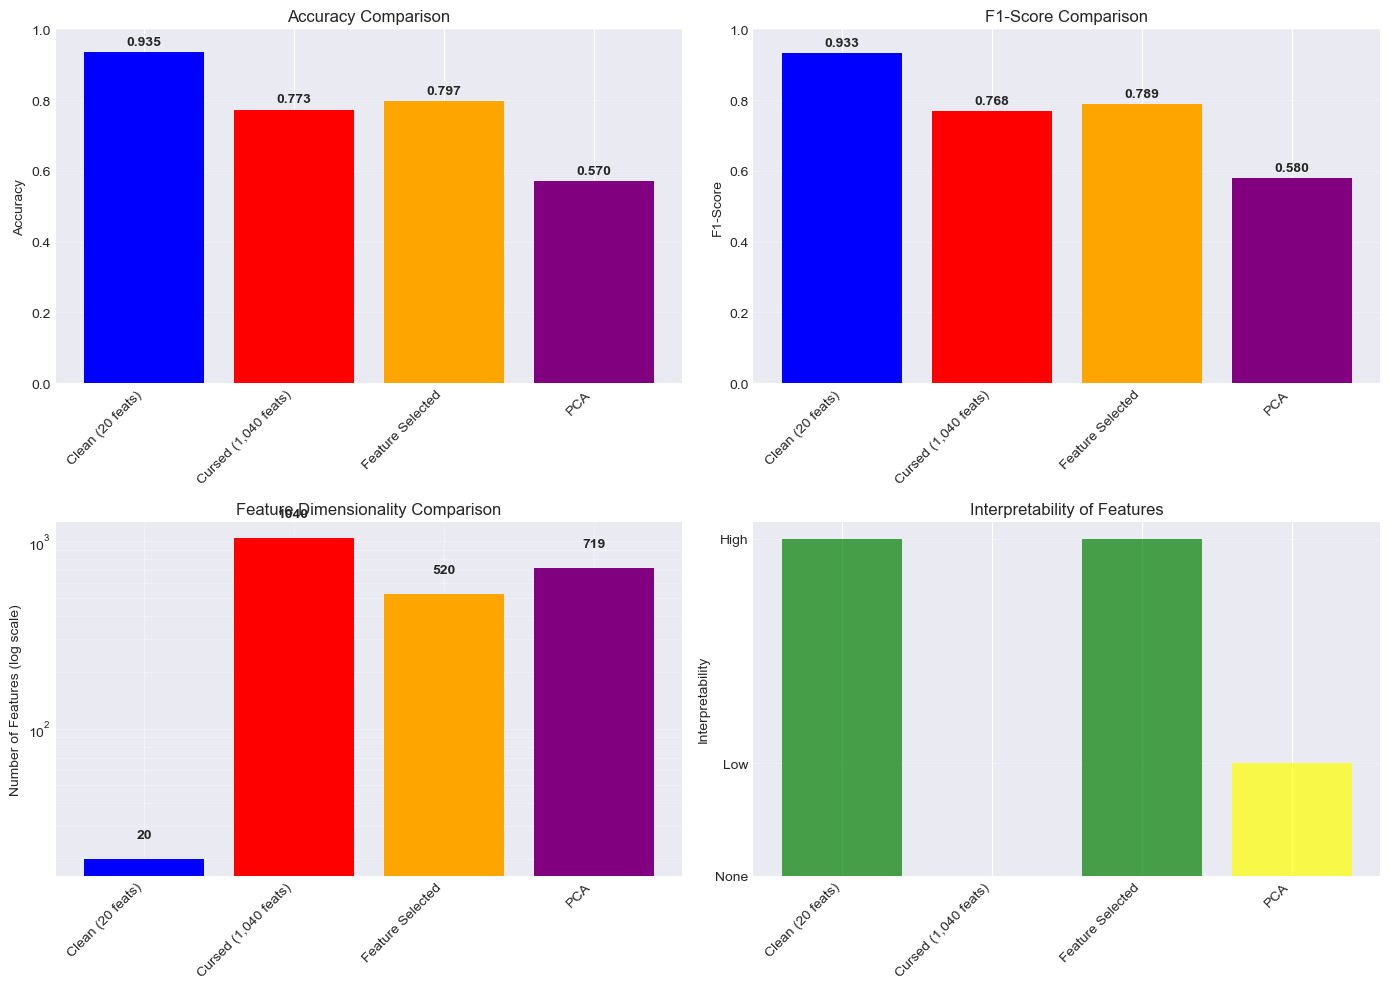

In [11]:
# ===== SECTION 6: FINAL SUMMARY =====

print("\nSection 6: Final Comparison & Decision Logic\n")

# Create summary DataFrame
summary_df = pd.DataFrame(results_comparison)
print(summary_df.to_string(index=False))

# Visualization: Comparison charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
axes[0, 0].bar(range(len(summary_df)), summary_df['Accuracy'].values, color=['blue', 'red', 'orange', 'purple'])
axes[0, 0].set_xticks(range(len(summary_df)))
axes[0, 0].set_xticklabels(summary_df['Setup'].values, rotation=45, ha='right')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].set_ylim(0, 1)
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(summary_df['Accuracy'].values):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(range(len(summary_df)), summary_df['F1-Score'].values, color=['blue', 'red', 'orange', 'purple'])
axes[0, 1].set_xticks(range(len(summary_df)))
axes[0, 1].set_xticklabels(summary_df['Setup'].values, rotation=45, ha='right')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('F1-Score Comparison')
axes[0, 1].set_ylim(0, 1)
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(summary_df['F1-Score'].values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

# Feature count comparison (log scale)
axes[1, 0].bar(range(len(summary_df)), summary_df['Num Features'].values, color=['blue', 'red', 'orange', 'purple'])
axes[1, 0].set_xticks(range(len(summary_df)))
axes[1, 0].set_xticklabels(summary_df['Setup'].values, rotation=45, ha='right')
axes[1, 0].set_ylabel('Number of Features (log scale)')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Feature Dimensionality Comparison')
axes[1, 0].grid(True, alpha=0.3, which='both')
for i, v in enumerate(summary_df['Num Features'].values):
    axes[1, 0].text(i, v * 1.3, f'{v}', ha='center', fontsize=10, fontweight='bold')

# Interpretability qualitative
interpretability_map = {'High': 3, 'Low': 1, 'None': 0}
interp_values = [interpretability_map.get(x, 0) for x in summary_df['Interpretability'].values]
colors_interp = ['green' if x == 'High' else 'yellow' if x == 'Low' else 'red' for x in summary_df['Interpretability'].values]
axes[1, 1].bar(range(len(summary_df)), interp_values, color=colors_interp, alpha=0.7)
axes[1, 1].set_xticks(range(len(summary_df)))
axes[1, 1].set_xticklabels(summary_df['Setup'].values, rotation=45, ha='right')
axes[1, 1].set_ylabel('Interpretability')
axes[1, 1].set_yticks([0, 1, 3])
axes[1, 1].set_yticklabels(['None', 'Low', 'High'])
axes[1, 1].set_title('Interpretability of Features')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()